## Setup Local Runtime

**Windows (Command Prompt):**
```
C:\Users\Ryman\AppData\Local\Python\pythoncore-3.14-64\python.exe -m jupyter notebook --no-browser --NotebookApp.allow_origin="https://colab.research.google.com" --port=8888 --NotebookApp.port_retries=0
```
Copy the full URL it prints (including `?token=...`)

### Step 2 — Connect Colab to your local runtime
In this Colab notebook: click the **▾** next to **Connect** in the top right → **Connect to a local runtime** → paste the URL from above in the  → Connect. You should see "Connected (Local)".

Now you can run the cells below — they'll execute on your laptop where the motor is plugged in.

---
## 1. Install Dynamixel SDK and Imports

In [ ]:
!pip3 install -q dynamixel-sdk

In [ ]:
import time
import math
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from dynamixel_sdk import *

import pandas as pd
import numpy as np

from matplotlib.patches import FancyBboxPatch
import matplotlib.transforms as mtransforms

print("Dynamixel SDK imported successfully.")

Dynamixel SDK imported successfully.


---
## 2. Configuration

**Edit these values** to match your hardware setup.

In [ ]:
# ══════════════════════════════════════════════════════════════════
# HARDWARE CONFIGURATION — EDIT THESE
# ══════════════════════════════════════════════════════════════════

DXL_IDS          = [5, 1]        # (base joint, elbow joint)
BAUDRATE         = 1000000
PROTOCOL_VERSION = 2.0
DEVICENAME       = 'COM3'        # Adjust for your OS


# ── Control Table Addresses (MX-28AR Protocol 2.0) ───────────────
ADDR_OPERATING_MODE   = 11
ADDR_TORQUE_ENABLE    = 64
ADDR_GOAL_PWM         = 100
ADDR_PROFILE_VELOCITY = 112
ADDR_GOAL_POSITION    = 116
ADDR_PRESENT_VELOCITY = 128
ADDR_PRESENT_POSITION = 132

LEN_GOAL_PWM         = 2
LEN_PRESENT_VELOCITY = 4
LEN_PRESENT_POSITION = 4

PWM_CONTROL_MODE      = 16
POSITION_CONTROL_MODE = 3

PWM_FULL_SCALE = 885
SUPPLY_VOLTAGE = 12.0

# ── Motor Zero Offsets (from calibration: arm flat-right) ────────
Q1_OFFSET_DEG = 97.47
Q2_OFFSET_DEG = 188.96
Q1_OFFSET_RAD = math.radians(Q1_OFFSET_DEG)
Q2_OFFSET_RAD = math.radians(Q2_OFFSET_DEG)

# ── Conversions ──────────────────────────────────────────────────
DEG_PER_TICK = 360.0 / 4096
RAD_PER_TICK = (2.0 * math.pi) / 4096
VEL_RAD_PER_S_PER_TICK = 0.229 * 2.0 * math.pi / 60.0

# ── Manipulator Parameters ───────────────────────────────────────
L1       = 0.175                 # link 1 length [m]  (175 mm)
L2       = 0.175                 # link 2 length [m]  (175 mm)

# ── Control Loop ─────────────────────────────────────────────────
CONTROL_FREQ_HZ = 240.0

# ── DC Motor Model ───────────────────────────────────────────────
KT_NM_PER_A    = 1.78
R_OHM          = 8.57
KE_V_S_PER_RAD = 12.0 / 5.76

In [ ]:
# ── Pen (Motor 2) Positions ──────────────────────────────────────

PEN_MOTOR_ID     = 3             # Z-axis pen lift/drop motor

# max angle range (150, 50) --> 150 top 50 bottom

PEN_UP_DEG       = 95.0         # retracted position
PEN_DOWN_DEG     = 25.0         # dot-making position
# PEN_DOWN_MID     = 59.0         # mid-dot-making position
PEN_DOWN_SMALL   = 69.7           # small dot-making position
PEN_DWELL_S      = 0.05           # how long pen stays down to make a dot
N_STEPS          = 5

pen_angles_deg = np.linspace(PEN_DOWN_SMALL, PEN_DOWN_DEG, N_STEPS)
print("Dot sizes to angles (smallest to biggest)")
for i, angle in enumerate(pen_angles_deg):
    print(f"Step {i}: {angle}°")

Dot sizes to angles (smallest to biggest)
Step 0: 69.7°
Step 1: 58.525000000000006°
Step 2: 47.35°
Step 3: 36.175°
Step 4: 25.0°


---
## 3. Helper Functions


In [ ]:
class FixedFrequencyLoopManager:
    """Sleep until the next tick of a fixed-rate loop."""
    def __init__(self, frequency_Hz: float):
        self.period_s = 1.0 / float(frequency_Hz)
        self._next_tick = None

    def sleep(self):
        now = time.time()
        if self._next_tick is None:
            self._next_tick = now + self.period_s
            return
        dt = self._next_tick - now
        if dt > 0:
            time.sleep(dt)
        self._next_tick += self.period_s


def deg_to_pos_ticks(angle_deg: float) -> int:
    return int(round(angle_deg / DEG_PER_TICK)) % 4096

def pos_ticks_to_deg(ticks: int) -> float:
    return (ticks % 4096) * DEG_PER_TICK

def vel_ticks_to_rad_per_s(ticks_signed: int) -> float:
    if ticks_signed >= (1 << 31):
        ticks_signed -= (1 << 32)
    return ticks_signed * VEL_RAD_PER_S_PER_TICK

def pos_ticks_to_rad(ticks_unsigned: int) -> float:
    return (ticks_unsigned % 4096) * RAD_PER_TICK

def _signed_deg_err(measured_deg: float, target_deg: float) -> float:
    return (measured_deg - target_deg + 540.0) % 360.0 - 180.0

def goto_home_via_position_mode(
    q_home_deg,
    pos_tol_deg: float = 1.0,
    vel_tol_rad_per_s: float = 0.05,
    settle_time_s: float = 0.5,
    timeout_s: float = 10.0,
    profile_velocity: int = 100,
):
    current_deg = []
    for dxl_id in DXL_IDS:
        pos_raw, _, _ = packetHandler.read4ByteTxRx(
            portHandler, dxl_id, ADDR_PRESENT_POSITION)
        current_deg.append(pos_ticks_to_deg(pos_raw))

    print(f"Homing... (current: {[f'{a:.1f}°' for a in current_deg]}, "
          f"target: {q_home_deg})")

    for dxl_id in DXL_IDS:
        packetHandler.write1ByteTxRx(portHandler, dxl_id, ADDR_TORQUE_ENABLE, 0)
        packetHandler.write1ByteTxRx(portHandler, dxl_id, ADDR_OPERATING_MODE, POSITION_CONTROL_MODE)
        packetHandler.write4ByteTxRx(portHandler, dxl_id, ADDR_PROFILE_VELOCITY, profile_velocity)
        packetHandler.write1ByteTxRx(portHandler, dxl_id, ADDR_TORQUE_ENABLE, 1)

    for dxl_id, ang_deg in zip(DXL_IDS, q_home_deg, strict=True):
        packetHandler.write4ByteTxRx(portHandler, dxl_id, ADDR_GOAL_POSITION, deg_to_pos_ticks(ang_deg))

    settle_start = None
    t0 = time.time()
    while True:
        if time.time() - t0 > timeout_s:
            raise RuntimeError(f"Homing did not converge within {timeout_s}s.")
        all_ok = True
        for dxl_id, ang_deg in zip(DXL_IDS, q_home_deg, strict=True):
            pos_raw, _, _ = packetHandler.read4ByteTxRx(portHandler, dxl_id, ADDR_PRESENT_POSITION)
            vel_raw, _, _ = packetHandler.read4ByteTxRx(portHandler, dxl_id, ADDR_PRESENT_VELOCITY)
            if abs(_signed_deg_err(pos_ticks_to_deg(pos_raw), ang_deg)) > pos_tol_deg or \
               abs(vel_ticks_to_rad_per_s(vel_raw)) > vel_tol_rad_per_s:
                all_ok = False
                break
        if all_ok:
            if settle_start is None:
                settle_start = time.time()
            elif time.time() - settle_start >= settle_time_s:
                break
        else:
            settle_start = None
        time.sleep(0.02)
    print("Homed.")


def enable_pwm_mode():
    for dxl_id in DXL_IDS:
        packetHandler.write2ByteTxRx(portHandler, dxl_id, ADDR_GOAL_PWM, 0)
        packetHandler.write1ByteTxRx(portHandler, dxl_id, ADDR_TORQUE_ENABLE, 0)
        packetHandler.write1ByteTxRx(portHandler, dxl_id, ADDR_OPERATING_MODE, PWM_CONTROL_MODE)
        packetHandler.write1ByteTxRx(portHandler, dxl_id, ADDR_TORQUE_ENABLE, 1)
    time.sleep(0.1)

def motor_deg_to_kin_rad(q_motor_deg):
    """Convert raw motor degrees to kinematic radians."""
    return np.array([
        math.radians(q_motor_deg[0] - Q1_OFFSET_DEG),
        -math.radians(q_motor_deg[1] - Q2_OFFSET_DEG),
    ])

---
## 4. Kinematics: FK, Jacobian, IK Functions

In [ ]:
def forward_kinematics(q_kin_rad):
    q1 = q_kin_rad[0]
    q2 = q_kin_rad[1]
    x = L1 * math.cos(q1) + L2 * math.cos(q1 + q2)
    y = L1 * math.sin(q1) + L2 * math.sin(q1 + q2)
    return np.array([x, y])

def inverse_kinematics(x, y, elbow_up=True):
    r_sq = x**2 + y**2
    cos_q2 = np.clip((r_sq - L1**2 - L2**2) / (2*L1*L2), -1.0, 1.0)
    q2_kin = -math.acos(cos_q2) if elbow_up else math.acos(cos_q2)
    q1_kin = math.atan2(y, x) - math.atan2(L2*math.sin(q2_kin), L1 + L2*math.cos(q2_kin))
    q1_motor = q1_kin + Q1_OFFSET_RAD
    q2_motor = -q2_kin + Q2_OFFSET_RAD
    return np.array([q1_motor, q2_motor])

def jacobian_matrix(q_kin_rad):
    q1, q2 = q_kin_rad[0], q_kin_rad[1]
    s1, c1 = math.sin(q1), math.cos(q1)
    s12, c12 = math.sin(q1 + q2), math.cos(q1 + q2)
    return np.array([
        [-L1*s1 - L2*s12,  -L2*s12],
        [ L1*c1 + L2*c12,   L2*c12],
    ])

def arm_joints_mm(q_motor_deg):
    """Returns (base, elbow, ee) in mm from raw motor degrees."""
    q_kin = motor_deg_to_kin_rad(q_motor_deg)
    j0 = np.array([0.0, 0.0])
    j1 = np.array([L1 * math.cos(q_kin[0]), L1 * math.sin(q_kin[0])]) * 1000
    ee = forward_kinematics(q_kin) * 1000
    return j0, j1, ee

---
## 5. Motor Functions

In [ ]:
def read_current_position_deg():
    """Open port, read both motor positions, close port.
    Returns [deg, deg] in raw motor encoder space."""
    ph = PortHandler(DEVICENAME)
    pk = PacketHandler(PROTOCOL_VERSION)
    if not ph.openPort():
        raise RuntimeError(f"Failed to open port {DEVICENAME}.")
    if not ph.setBaudRate(BAUDRATE):
        raise RuntimeError(f"Failed to set baud rate {BAUDRATE}.")
    try:
        pos_deg = []
        for dxl_id in DXL_IDS:
            pos_raw, _, _ = pk.read4ByteTxRx(ph, dxl_id, ADDR_PRESENT_POSITION)
            pos_deg.append(pos_ticks_to_deg(pos_raw))
        return pos_deg
    finally:
        ph.closePort()

def test_swing(swing_deg=25.0, profile_velocity=60):
    """Move each joint ±swing_deg around home, then return."""
    portHandler   = PortHandler(DEVICENAME)
    packetHandler = PacketHandler(PROTOCOL_VERSION)

    if not portHandler.openPort():
        raise RuntimeError(f"Failed to open port {DEVICENAME}.")
    if not portHandler.setBaudRate(BAUDRATE):
        raise RuntimeError(f"Failed to set baud rate {BAUDRATE}.")
    print(f"Port opened: {DEVICENAME}")
    print(f"Home (q_initial): {q_initial}")

    waypoints = [
        q_initial,
        [q_initial[0] + swing_deg, q_initial[1] + swing_deg],
        q_initial,
        [q_initial[0] - swing_deg, q_initial[1] - swing_deg],
        q_initial,
    ]

    STUCK_TIMEOUT_S = 5.0
    STUCK_CHECK_INTERVAL = 0.5
    STUCK_THRESHOLD_DEG = 0.2

    try:
        for i, wp in enumerate(waypoints):
            label = ["Home", f"+{swing_deg}°", "Home", f"−{swing_deg}°", "Home"][i]
            print(f"\n[{i+1}/{len(waypoints)}] Moving to {label}: {[f'{w:.2f}' for w in wp]}")

            for dxl_id in DXL_IDS:
                packetHandler.write1ByteTxRx(portHandler, dxl_id, ADDR_TORQUE_ENABLE, 0)
                packetHandler.write1ByteTxRx(portHandler, dxl_id, ADDR_OPERATING_MODE, POSITION_CONTROL_MODE)
                packetHandler.write4ByteTxRx(portHandler, dxl_id, ADDR_PROFILE_VELOCITY, profile_velocity)
                packetHandler.write1ByteTxRx(portHandler, dxl_id, ADDR_TORQUE_ENABLE, 1)
            for dxl_id, ang_deg in zip(DXL_IDS, wp):
                packetHandler.write4ByteTxRx(portHandler, dxl_id, ADDR_GOAL_POSITION, deg_to_pos_ticks(ang_deg))

            t0 = time.time()
            prev_pos = None
            while True:
                time.sleep(STUCK_CHECK_INTERVAL)
                elapsed = time.time() - t0

                cur_pos = []
                all_arrived = True
                for dxl_id, ang_deg in zip(DXL_IDS, wp):
                    pos_raw, _, _ = packetHandler.read4ByteTxRx(portHandler, dxl_id, ADDR_PRESENT_POSITION)
                    cur_deg = pos_ticks_to_deg(pos_raw)
                    cur_pos.append(cur_deg)
                    if abs(_signed_deg_err(cur_deg, ang_deg)) > 1.0:
                        all_arrived = False

                if all_arrived:
                    print(f"  Arrived at: {[f'{a:.2f}°' for a in cur_pos]}")
                    break

                if prev_pos is not None:
                    max_delta = max(abs(c - p) for c, p in zip(cur_pos, prev_pos))
                    if max_delta < STUCK_THRESHOLD_DEG and elapsed > 2.0:
                        print(f"  ⚠ STUCK — position not changing (delta={max_delta:.3f}°). "
                              f"Current: {[f'{a:.2f}°' for a in cur_pos]}")
                        raise RuntimeError("Motor stuck, terminating test.")

                if elapsed > STUCK_TIMEOUT_S:
                    print(f"  ⚠ TIMEOUT after {STUCK_TIMEOUT_S}s. "
                          f"Current: {[f'{a:.2f}°' for a in cur_pos]}")
                    raise RuntimeError("Waypoint timeout, terminating test.")

                prev_pos = cur_pos

            time.sleep(0.3)

        print("\n✓ Test complete. Arm back at home.")

    finally:
        for dxl_id in DXL_IDS:
            try:
                packetHandler.write1ByteTxRx(portHandler, dxl_id, ADDR_TORQUE_ENABLE, 0)
            except Exception:
                pass
        portHandler.closePort()
        print("Port closed.")

---
## 6. Pen Functions

In [ ]:
def pen_stamp(port_handler, packet_handler, dot_size, idx, down_deg,
              dow_deg_small=PEN_DOWN_SMALL, up_deg=PEN_UP_DEG,
              dwell_s=PEN_DWELL_S, pos_tol_deg=0.7, timeout_s=1.0):
    """Pen already in position mode + torque on (set by retract_pen).
       Dot SIZE set by drop DEPTH; dwell shortened for deeper (bigger) dots
       to offset their longer in-contact over-travel time."""
    dxl_id = PEN_MOTOR_ID

    PEN_DROP_VEL    = 240   # controlled drop speed
    PEN_RETRACT_VEL = 300   # retract at full speed
    MIN_DWELL_S     = 0.02  # floor so big dots still lay ink
    dot_size_name   = ["small", "kinda small", "mid", "kinda big", "big"]

    # depth sets the dot size
    target_down = (dow_deg_small - idx*0.05) if dot_size == 0 else down_deg

    # shorter dwell for deeper dots (more travel -> already longer contact)
    ref_travel = abs(up_deg - PEN_DOWN_SMALL)        # smallest stroke
    travel     = max(abs(up_deg - target_down), 1e-3)
    dwell      = max(MIN_DWELL_S, dwell_s * ref_travel / travel)/4

    def _go_to(target_deg, vel):
        packet_handler.write4ByteTxRx(port_handler, dxl_id,
                                      ADDR_PROFILE_VELOCITY, int(vel))
        packet_handler.write4ByteTxRx(port_handler, dxl_id,
                                      ADDR_GOAL_POSITION, deg_to_pos_ticks(target_deg))
        t0 = time.time()
        cur_deg = None
        print(f"Target Velocity: {vel}")
        while time.time() - t0 < timeout_s:
            try:
                pos_raw, comm, _ = packet_handler.read4ByteTxRx(
                    port_handler, dxl_id, ADDR_PRESENT_POSITION)
            except IndexError:
                continue                       # truncated status packet, re-poll
            if comm != COMM_SUCCESS:
                continue                       # dropped read, re-poll
            cur_deg = pos_ticks_to_deg(pos_raw)
            if abs(_signed_deg_err(cur_deg, target_deg)) < pos_tol_deg:
                print(f"Reached {cur_deg:.1f}°, target {target_deg:.1f}°")
                return True
            time.sleep(0.002)                  # throttle poll, cut bus collisions
        cur_str = f"{cur_deg:.1f}°" if cur_deg is not None else "unknown"
        print(f"Pen timeout: stopped at {cur_str}, trying to reach {target_deg:.1f}°")
        return False

    _go_to(target_down, PEN_DROP_VEL)
    print(f"stamped a {dot_size_name[dot_size]} dot!")
    time.sleep(dwell)
    _go_to(up_deg, PEN_RETRACT_VEL)

---
## 7. Task-Space PID Controller (Hardware)

In [ ]:
class TaskSpacePIDController:
    """Point-to-point task-space PID for halftone dot placement."""

    J1_MIN_DEG, J1_MAX_DEG = 45.0, 280.0
    J2_MIN_DEG, J2_MAX_DEG = 79.0, 330.0

    def __init__(self, K_P, K_I, K_D,
                 q_initial_deg,
                 waypoints_m,
                 dot_size,
                 pen_angles_deg,
                 arrive_tol_m=0.001,
                 settle_s=0.15,
                 integral_clamp=10.0,
                 control_freq_Hz=CONTROL_FREQ_HZ,
                 velocity_filter_alpha=0.5):

        self.q_initial_deg = list(q_initial_deg)
        self.K_P = np.asarray(K_P, dtype=np.double)
        self.K_I = np.asarray(K_I, dtype=np.double)
        self.K_D = np.asarray(K_D, dtype=np.double)

        self.waypoints = np.asarray(waypoints_m, dtype=np.double)
        self.dot_size = np.asarray(dot_size, dtype=int)
        self.n_waypoints = len(self.waypoints)
        self.arrive_tol = float(arrive_tol_m)
        self.settle_s = float(settle_s)

        self.integral_clamp = integral_clamp
        self.loop_manager = FixedFrequencyLoopManager(control_freq_Hz)
        self.dt = 1.0 / control_freq_Hz
        self._qdot_filt = np.zeros(2)
        self._alpha = velocity_filter_alpha

        # Logging
        self.time_stamps = []
        self.joint_position_history = []
        self.ee_position_history = []
        self.ee_desired_history = []
        self.task_error_history = []
        self.torque_history = []
        self.waypoint_logs = []

    def _read_state(self):
        groupSyncReadState.txRxPacket()
        q_kin = np.zeros(2)
        q_motor_deg = np.zeros(2)
        qdot = np.zeros(2)
        for i, dxl_id in enumerate(DXL_IDS):
            v_ticks = groupSyncReadState.getData(dxl_id, ADDR_PRESENT_VELOCITY, LEN_PRESENT_VELOCITY)
            p_ticks = groupSyncReadState.getData(dxl_id, ADDR_PRESENT_POSITION, LEN_PRESENT_POSITION)
            qdot[i] = vel_ticks_to_rad_per_s(v_ticks)
            q_kin[i] = pos_ticks_to_rad(p_ticks)
            q_motor_deg[i] = pos_ticks_to_deg(p_ticks)

        q_kin[0] -= Q1_OFFSET_RAD
        q_kin[1] = -(q_kin[1] - Q2_OFFSET_RAD)
        qdot[1] = -qdot[1]

        self._qdot_filt = self._alpha * qdot + (1 - self._alpha) * self._qdot_filt
        return q_kin, self._qdot_filt, q_motor_deg

    def _check_joint_limits(self, q_motor_deg):
        if q_motor_deg[0] < self.J1_MIN_DEG or q_motor_deg[0] > self.J1_MAX_DEG:
            return False
        if q_motor_deg[1] < self.J2_MIN_DEG or q_motor_deg[1] > self.J2_MAX_DEG:
            return False
        return True

    def _write_pwm(self, pwm_values):
        groupSyncWritePWM.clearParam()
        for dxl_id, pwm in zip(DXL_IDS, pwm_values, strict=True):
            pwm = int(np.clip(pwm, -PWM_FULL_SCALE, PWM_FULL_SCALE))
            if pwm < 0:
                pwm += (1 << 16)
            groupSyncWritePWM.addParam(dxl_id, bytes([DXL_LOBYTE(pwm), DXL_HIBYTE(pwm)]))
        groupSyncWritePWM.txPacket()

    def _torque_to_pwm(self, u_nm, qdot_rad_per_s):
        """Convert kinematic torques → PWM via DC motor model."""
        u_motor = u_nm.copy()
        u_motor[1] = -u_motor[1]
        qdot_motor = qdot_rad_per_s.copy()
        qdot_motor[1] = -qdot_motor[1]
        V = (R_OHM / KT_NM_PER_A) * u_motor + KE_V_S_PER_RAD * qdot_motor
        pwm = (V / SUPPLY_VOLTAGE) * PWM_FULL_SCALE

        # Dead-zone compensation: bump small nonzero PWM above friction threshold
        MIN_PWM = 30
        for i in range(len(pwm)):
            if abs(pwm[i]) > 1 and abs(pwm[i]) < MIN_PWM:
                pwm[i] = MIN_PWM * np.sign(pwm[i])

        return [int(round(p)) for p in np.clip(pwm, -PWM_FULL_SCALE, PWM_FULL_SCALE)]

    def control_loop(self, log_every=3):
        """Move to each waypoint, stamp, repeat.
           log_every: append to history lists once per N iterations
           (control runs every iteration; only logging is thinned)."""
        t_start = time.time()

        for wp_idx in range(self.n_waypoints):
            print(f"\n── Starting point {wp_idx + 1}/{self.n_waypoints} ──")
            x_d = self.waypoints[wp_idx]

            integral_error = np.zeros(2)
            settled_since = None
            wp_start_time = time.time()
            log_start_idx = len(self.time_stamps)

            prev_e = None          # control state, updated every iteration
            loop_i = 0

            while True:
                q_rad, qdot_rad, q_motor_deg = self._read_state()
                t = time.time() - t_start

                if not self._check_joint_limits(q_motor_deg):
                    self._write_pwm([0, 0])
                    print(f"JOINT LIMIT at t={t:.2f}s — aborting.")
                    return

                x = forward_kinematics(q_rad)
                J = jacobian_matrix(q_rad)
                xdot = J @ qdot_rad

                e    = x_d - x
                edot = -xdot    # xdot_d = 0 for static setpoint

                integral_error += e * self.dt
                integral_error = np.clip(integral_error,
                                         -self.integral_clamp,
                                         self.integral_clamp)

                # Reset integral on overshoot (sign change) — uses prev_e,
                # updated every iteration so it's independent of logging rate
                if prev_e is not None:
                    for axis in range(2):
                        if e[axis] * prev_e[axis] < 0:
                            integral_error[axis] = 0.0
                prev_e = e

                F   = self.K_P @ e + self.K_I @ integral_error + self.K_D @ edot
                tau = J.T @ F

                pwm_command = self._torque_to_pwm(tau, np.zeros(2))
                self._write_pwm(pwm_command)

                err_mm = np.linalg.norm(e) * 1000

                # ── Thinned logging ──────────────────────────────
                if loop_i % log_every == 0:
                    self.time_stamps.append(t)
                    self.joint_position_history.append(q_rad)
                    self.ee_position_history.append(x)
                    self.ee_desired_history.append(np.array(x_d))
                    self.task_error_history.append(e)
                    self.torque_history.append(tau)

                    if len(self.time_stamps) % 40 == 0:
                        print(f"  t={t:.2f}s  x=[{x[0]*1000:.1f}, {x[1]*1000:.1f}]mm  "
                              f"xd=[{x_d[0]*1000:.1f}, {x_d[1]*1000:.1f}]mm  "
                              f"|e|={err_mm:.2f}mm  "
                              f"q_motor=[{q_motor_deg[0]:.1f}, {q_motor_deg[1]:.1f}]°  "
                              f"PWM={pwm_command}")

                loop_i += 1

                # ── Check arrival ────────────────────────────────
                if err_mm / 1000 < self.arrive_tol:
                    if settled_since is None:
                        settled_since = time.time()
                    elif time.time() - settled_since >= self.settle_s:
                        break
                else:
                    settled_since = None

                self.loop_manager.sleep()

            # ── Arrived: hold position while stamping ────────────
            print(f"(point {wp_idx + 1} out of {self.n_waypoints} reached)  "
                  f"EE=[{x[0]*1000:.1f}, {x[1]*1000:.1f}] mm  "
                  f"settle={time.time() - wp_start_time:.2f}s")

            self.waypoint_logs.append({
                'idx': wp_idx,
                'target_mm': x_d * 1000,
                'actual_mm': x * 1000,
                'error_mm': np.linalg.norm(e) * 1000,
                'settle_time_s': time.time() - wp_start_time,
                'log_start': log_start_idx,
                'log_end': len(self.time_stamps),
            })

            print("  Dropping pen...")
            pen_stamp(portHandler, packetHandler, self.dot_size[wp_idx], wp_idx,
                      pen_angles_deg[self.dot_size[wp_idx]])

            self._write_pwm([0, 0])

        self._write_pwm([0, 0])
        print(f"\n All {self.n_waypoints} dots complete.")

---
## 8. Set Home Position (if set home is true)

In [ ]:
set_home = True

In [ ]:
# ══════════════════════════════════════════════════════════════════
# SET NEW HOME — Read current motor positions and use as home
# ══════════════════════════════════════════════════════════════════

if set_home is True:
    q_initial = read_current_position_deg()
    q_initial = [round(a, 2) for a in q_initial]
    print(f"q_initial set to: {q_initial}")
else:
    q_initial = [145.81, 84.46]
    print(f"flag false, q_initial set to: {q_initial}")

q_initial set to: [257.43, 318.87]


In [ ]:
set_home = False

---
## 9. Test motor

In [ ]:
test_flag = False

In [ ]:
if test_flag is True:
  test_swing()

---
## 10. Traj Gen (specified points)

Home EE:  (-44.8, 162.4) mm
Dots:     12 (2 eyes + 5 mouth)
X range:  [-76.0, -13.6] mm
Y range:  [126.7, 186.4] mm
X size:   62.4 mm
Y size:   59.8 mm


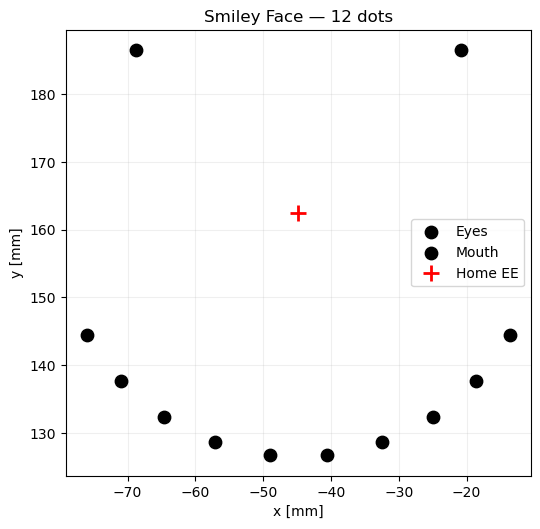

In [ ]:
# ══════════════════════════════════════════════════════════════════
# TRAJECTORY — smiley face dots (centered at home EE)
# ══════════════════════════════════════════════════════════════════

q_init_rad = motor_deg_to_kin_rad(q_initial)
HOME_EE = forward_kinematics(q_init_rad)

# All offsets in mm from HOME_EE, then converted to meters
# Face is ~60mm wide, ~60mm tall

# ── Eyes: 2 dots ─────────────────────────────────────────────────
eye_left  = [-12,  12]   # mm offset from center
eye_right = [ 12,  12]

# ── Mouth: 5 dots in a smile arc ────────────────────────────────
mouth_angles = np.linspace(np.radians(210), np.radians(330), 10)
mouth_radius = 18  # mm
mouth_dots = [[mouth_radius * np.cos(a), mouth_radius * np.sin(a)]
              for a in mouth_angles]

# ── Combine all dots ─────────────────────────────────────────────
FACE_SCALE = 2.0

dots_mm = np.array([eye_left, eye_right] + mouth_dots) * FACE_SCALE
# Convert to meters and shift to home EE
traj_points_m = dots_mm / 1000.0 + HOME_EE
traj_dt = 1

print(f"Home EE:  ({HOME_EE[0]*1000:.1f}, {HOME_EE[1]*1000:.1f}) mm")
print(f"Dots:     {len(traj_points_m)} (2 eyes + 5 mouth)")
print(f"X range:  [{traj_points_m[:,0].min()*1000:.1f}, {traj_points_m[:,0].max()*1000:.1f}] mm")
print(f"Y range:  [{traj_points_m[:,1].min()*1000:.1f}, {traj_points_m[:,1].max()*1000:.1f}] mm")

x_size = (traj_points_m[:,0].max() - traj_points_m[:,0].min()) * 1000
y_size = (traj_points_m[:,1].max() - traj_points_m[:,1].min()) * 1000
print(f"X size:   {x_size:.1f} mm")
print(f"Y size:   {y_size:.1f} mm")

# ── Preview dot pattern ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
traj_mm = traj_points_m * 1000
ax.scatter(traj_mm[:2, 0], traj_mm[:2, 1], s=80, c='black', zorder=3, label='Eyes')
ax.scatter(traj_mm[2:, 0], traj_mm[2:, 1], s=80, c='black', zorder=3, label='Mouth')
ax.plot(HOME_EE[0]*1000, HOME_EE[1]*1000, 'r+', ms=12, mew=2, label='Home EE')
ax.set_aspect('equal')
ax.set_xlabel('x [mm]')
ax.set_ylabel('y [mm]')
ax.set_title(f'Smiley Face — {len(traj_mm)} dots')
ax.legend()
ax.grid(True, alpha=0.2)
plt.show()

---
## 10. Trajectory Generation (from CSV)

file:  halftone_blackV7.csv found.



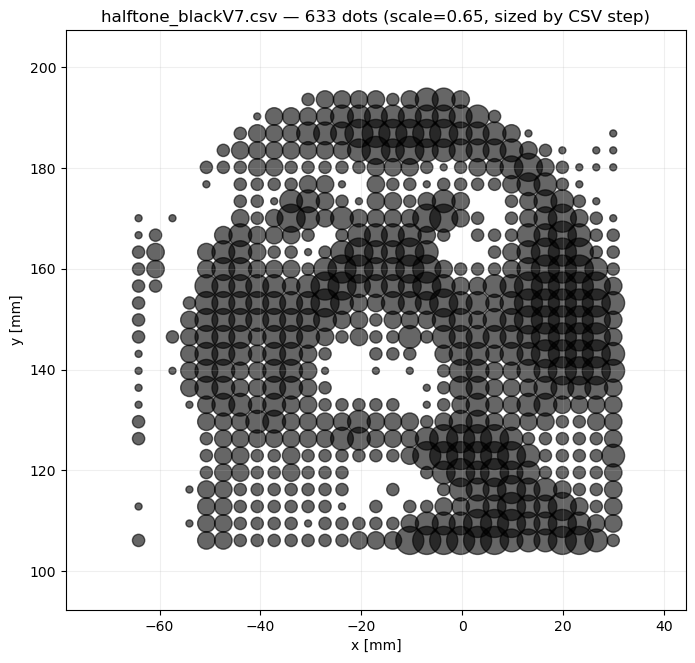

Loaded 633 dots from halftone_blackV7.csv (scale=0.65)
Image center shifted to EE at (-12.9, 147.6) mm
X range: [-64.2, 30.0] mm
Y range: [106.1, 193.6] mm
X size:   94.1 mm
Y size:   87.4 mm


In [ ]:
# file_name = "3aJxyz_am_dots.csv"
file_name = "halftone_blackV7.csv"

SCALE = .65

csv_path = rf"C:\Users\Ryman\Desktop\UCLA\2025-26\Spring 2026\MAE263C\Project\{file_name}"
print("file: ", file_name, "found.\n")
df = pd.read_csv(csv_path)

# ── Detect units from column names ───────────────────────────────
cols = [c.lower() for c in df.columns]
if any('inch' in c for c in cols):
    print("Detected INCHES — converting to mm")
    x_mm = df.iloc[:, 0].values * 25.4
    y_mm = df.iloc[:, 1].values * 25.4
else:
    x_mm = df.iloc[:, 0].values
    y_mm = df.iloc[:, 1].values

# size INDEX from CSV (0 … N_STEPS-1) — this is what the controller consumes
dia_mm = df.iloc[:, 2].values.astype(int)

traj_points_m = np.column_stack([x_mm, -1*y_mm]) / 1000.0

# ── Scale around image center ────────────────────────────────────
image_center = traj_points_m.mean(axis=0)
traj_points_m = (traj_points_m - image_center) * SCALE + image_center

traj_points_m[:, 1] = 2 * image_center[1] - traj_points_m[:, 1]

# ── Recenter: image center → home EE position ────────────────────
q_init_rad = motor_deg_to_kin_rad(q_initial)
HOME_EE = forward_kinematics(q_init_rad)

traj_points_m = traj_points_m - image_center + HOME_EE

x_size = (traj_points_m[:,0].max() - traj_points_m[:,0].min()) * 1000
y_size = (traj_points_m[:,1].max() - traj_points_m[:,1].min()) * 1000

# ── Preview with dot sizes (sized by the CSV number) ─────────────
DOT_MIN_MM   = 1.0
DOT_MAX_MM   = 4.0
DOT_SIZES_MM = np.linspace(DOT_MIN_MM, DOT_MAX_MM, N_STEPS)  # [1.0, 1.75, 2.5, 3.25, 4.0]
dot_sizes_mm = DOT_SIZES_MM[dia_mm]                          # index -> physical mm

fig, ax = plt.subplots(figsize=(8, 8))
traj_mm = traj_points_m * 1000

x_pad = (traj_mm[:, 0].max() - traj_mm[:, 0].min()) * 0.1 + 5
y_pad = (traj_mm[:, 1].max() - traj_mm[:, 1].min()) * 0.1 + 5
ax.set_xlim(traj_mm[:, 0].min() - x_pad, traj_mm[:, 0].max() + x_pad)
ax.set_ylim(traj_mm[:, 1].min() - y_pad, traj_mm[:, 1].max() + y_pad)
ax.set_aspect('equal')
fig.canvas.draw()

# draw each marker at its TRUE physical diameter so the preview
# matches the size number from the CSV
mm_to_pts = ax.transData.transform([1, 0])[0] - ax.transData.transform([0, 0])[0]
dot_s = (dot_sizes_mm * mm_to_pts) ** 2

ax.scatter(traj_mm[:, 0], traj_mm[:, 1], s=dot_s, c='black', alpha=0.6)
ax.set_xlabel('x [mm]')
ax.set_ylabel('y [mm]')
ax.set_title(f'{file_name} — {len(traj_mm)} dots (scale={SCALE}, sized by CSV step)')
ax.grid(True, alpha=0.2)
plt.show()
print(f"Loaded {len(traj_points_m)} dots from {file_name} (scale={SCALE})")
print(f"Image center shifted to EE at ({HOME_EE[0]*1000:.1f}, {HOME_EE[1]*1000:.1f}) mm")
print(f"X range: [{traj_points_m[:,0].min()*1000:.1f}, {traj_points_m[:,0].max()*1000:.1f}] mm")
print(f"Y range: [{traj_points_m[:,1].min()*1000:.1f}, {traj_points_m[:,1].max()*1000:.1f}] mm")
print(f"X size:   {x_size:.1f} mm")
print(f"Y size:   {y_size:.1f} mm")

---
## 11. Visualize Robot Arm and Traj

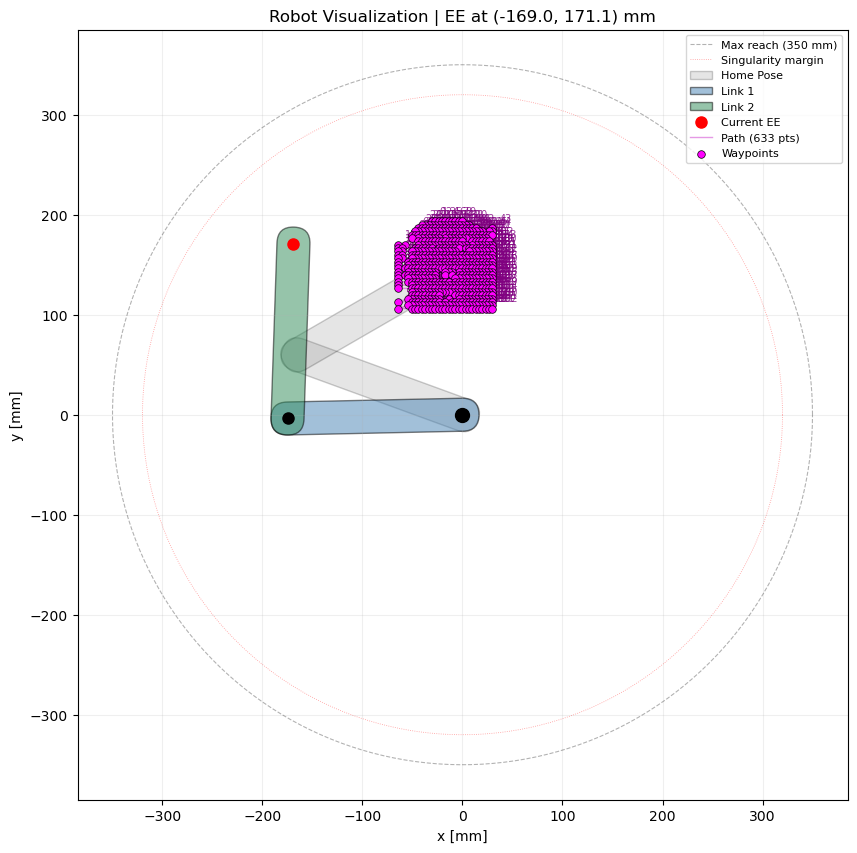

In [ ]:
q_current = read_current_position_deg()

home_ee_mm = forward_kinematics(motor_deg_to_kin_rad(q_initial)) * 1000
curr_ee_mm = forward_kinematics(motor_deg_to_kin_rad(q_current)) * 1000

j0_h, j1_h, ee_h = arm_joints_mm(q_initial)
j0_c, j1_c, ee_c = arm_joints_mm(q_current)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.set_aspect('equal')
ax.set_xlabel('x [mm]')
ax.set_ylabel('y [mm]')
ax.grid(True, alpha=0.2)

R_MAX = (L1 + L2) * 1000
SINGULARITY_MARGIN_MM = 30.0
r_warn = R_MAX - SINGULARITY_MARGIN_MM

theta_full = np.linspace(0, 2*np.pi, 200)
ax.plot(R_MAX * np.cos(theta_full), R_MAX * np.sin(theta_full),
        'k--', lw=0.8, alpha=0.3, label=f'Max reach ({R_MAX:.0f} mm)')
ax.plot(r_warn * np.cos(theta_full), r_warn * np.sin(theta_full),
        'r:', lw=0.6, alpha=0.4, label='Singularity margin')

LINK_WIDTH = 33.0

def draw_link(ax, p0, p1, color, alpha, label=None):
    dx = p1[0] - p0[0]
    dy = p1[1] - p0[1]
    length = np.sqrt(dx**2 + dy**2)
    angle = np.degrees(np.arctan2(dy, dx))
    pad = LINK_WIDTH / 2
    rect = FancyBboxPatch(
        (-pad, -LINK_WIDTH / 2), length + 2 * pad, LINK_WIDTH,
        boxstyle=f"round,pad=0,rounding_size={LINK_WIDTH/2}",
        facecolor=color, alpha=alpha, edgecolor='black', linewidth=1,
        label=label,
    )
    t = mtransforms.Affine2D().rotate_deg(angle).translate(p0[0], p0[1]) + ax.transData
    rect.set_transform(t)
    ax.add_patch(rect)

draw_link(ax, j0_h, j1_h, 'gray', 0.2)
draw_link(ax, j1_h, ee_h, 'gray', 0.2, label='Home Pose')
draw_link(ax, j0_c, j1_c, 'steelblue', 0.5, label='Link 1')
draw_link(ax, j1_c, ee_c, 'seagreen', 0.5, label='Link 2')

ax.plot(*j0_c, 'ko', ms=10, zorder=5)
ax.plot(*j1_c, 'ko', ms=8, zorder=5)
ax.plot(*ee_c, 'ro', ms=8, zorder=5, label='Current EE')

# ── Trajectory: path + individual points ─────────────────────────
traj_mm = traj_points_m * 1000
n_pts = len(traj_mm)
ax.plot(traj_mm[:, 0], traj_mm[:, 1], 'm-', lw=1.0, alpha=0.4, label=f'Path ({n_pts} pts)')
ax.scatter(traj_mm[:, 0], traj_mm[:, 1], s=30, c='magenta', edgecolors='black',
           linewidths=0.5, zorder=4, label='Waypoints')
# Number each point
for i, (px, py) in enumerate(traj_mm):
    ax.annotate(str(i), (px, py), textcoords="offset points",
                xytext=(5, 5), fontsize=7, color='purple', alpha=0.8)

ax.set_title(f"Robot Visualization | EE at ({curr_ee_mm[0]:.1f}, {curr_ee_mm[1]:.1f}) mm")
ax.legend(loc='upper right', fontsize=8)
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════
# Read current position and set it as current
# ══════════════════════════════════════════════════════════════════

q_current = read_current_position_deg()
print(f"Home (q_initial):       {q_initial}")
print(f"Current pos (kinematic): {[f'{a:.4f}°' for a in q_current]}")

Home (q_initial):       [137.64, 71.89]
Current pos (kinematic): ['137.6367°', '71.8066°']


---
## 11. Tune Gains

In [ ]:
# ══════════════════════════════════════════════════════════════════
# PID GAINS
# ══════════════════════════════════════════════════════════════════

K_P = np.diag([17, 23])   # Proportional
K_I = np.diag([4.6, 4.6])   # Integral
K_D = np.diag([0.4, 0.17])   # Derivative

traj_dt = 1

INTEGRAL_CLAMP = 15.0          # anti-windup limit per axis

# ══════════════════════════════════════════════════════════════════
# THRESHOLD
# ══════════════════════════════════════════════════════════════════
ERROR_THRESHOLD_MM = 0.7
settling_time = 0.1

print("Gains set:")
print(f"  K_P diag = {np.diag(K_P)}")
print(f"  K_I diag = {np.diag(K_I)}")
print(f"  K_D diag = {np.diag(K_D)}")
print(f"  Integral clamp = {INTEGRAL_CLAMP}")

Gains set:
  K_P diag = [16 21]
  K_I diag = [5 5]
  K_D diag = [0.3  0.17]
  Integral clamp = 15.0


---
## 12. Trial

In [ ]:
# ══════════════════════════════════════════════════════════════════
# TRIAL — waypoint-by-waypoint halftone dotting
# connect → home → retract pen → PID waypoints (stamp each) → disconnect
# ══════════════════════════════════════════════════════════════════

portHandler   = PortHandler(DEVICENAME)
packetHandler = PacketHandler(PROTOCOL_VERSION)

if not portHandler.openPort():
    raise RuntimeError(f"Failed to open port {DEVICENAME}.")
if not portHandler.setBaudRate(BAUDRATE):
    raise RuntimeError(f"Failed to set baud rate {BAUDRATE}.")
print(f"Port opened: {DEVICENAME}")

# ── Ping all three motors ────────────────────────────────────────
for dxl_id in DXL_IDS + [PEN_MOTOR_ID]:
    _, comm_result, _ = packetHandler.ping(portHandler, dxl_id)
    if comm_result != COMM_SUCCESS:
        raise RuntimeError(
            f"Ping ID={dxl_id} failed: {packetHandler.getTxRxResult(comm_result)}")
print(f"All motors responding: {DXL_IDS + [PEN_MOTOR_ID]}")

# ── Print pen motor model for diagnostics ────────────────────────
model_raw, dxl_comm_result, dxl_error = packetHandler.read2ByteTxRx(
    portHandler, PEN_MOTOR_ID, 0)
print(f"Pen motor (ID {PEN_MOTOR_ID}) model number: {model_raw}  "
      f"(comm={packetHandler.getTxRxResult(dxl_comm_result)}, err={dxl_error})")
print("  (MX-28=30, XL430=1060, XL330=1190, AX-12A=12, XL-320=350)")
if model_raw not in (30, 29):  # 30 = MX-28(2.0), 29 = MX-28
    print(f"  ⚠ WARNING: control table addresses are for MX-28 — "
          f"model {model_raw} may use different addresses!")

# ── SyncRead / SyncWrite for XY joints ──────────────────────────
groupSyncReadState = GroupSyncRead(
    portHandler, packetHandler,
    ADDR_PRESENT_VELOCITY,
    LEN_PRESENT_VELOCITY + LEN_PRESENT_POSITION,
)
for dxl_id in DXL_IDS:
    groupSyncReadState.addParam(dxl_id)

groupSyncWritePWM = GroupSyncWrite(
    portHandler, packetHandler, ADDR_GOAL_PWM, LEN_GOAL_PWM,
)

def retract_pen(timeout_s=2.0):
    """Command pen to PEN_UP_DEG in position mode, wait for arrival."""
    packetHandler.write1ByteTxRx(portHandler, PEN_MOTOR_ID,
                                 ADDR_TORQUE_ENABLE, 0)
    packetHandler.write1ByteTxRx(portHandler, PEN_MOTOR_ID,
                                 ADDR_OPERATING_MODE, POSITION_CONTROL_MODE)
    packetHandler.write4ByteTxRx(portHandler, PEN_MOTOR_ID,
                                 ADDR_PROFILE_VELOCITY, 240)
    packetHandler.write1ByteTxRx(portHandler, PEN_MOTOR_ID,
                                 ADDR_TORQUE_ENABLE, 1)
    packetHandler.write4ByteTxRx(portHandler, PEN_MOTOR_ID,
                                 ADDR_GOAL_POSITION,
                                 deg_to_pos_ticks(PEN_UP_DEG))
    t0 = time.time()
    while time.time() - t0 < timeout_s:
        pos_raw, _, _ = packetHandler.read4ByteTxRx(
            portHandler, PEN_MOTOR_ID, ADDR_PRESENT_POSITION)
        cur_deg = pos_ticks_to_deg(pos_raw)
        if abs(_signed_deg_err(cur_deg, PEN_UP_DEG)) < 2.0:
            print(f"  Pen at {cur_deg:.1f}° (target {PEN_UP_DEG}°) — retracted.")
            return
        time.sleep(0.02)
    pos_raw, _, _ = packetHandler.read4ByteTxRx(
        portHandler, PEN_MOTOR_ID, ADDR_PRESENT_POSITION)
    print(f"  ⚠ Pen retract TIMEOUT — currently at {pos_ticks_to_deg(pos_raw):.1f}° "
          f"(target {PEN_UP_DEG}°)")

try:
    # ── 1. Retract pen ───────────────────────────────────────────
    print("\n── Step 1: Retracting pen ──")
    retract_pen(timeout_s=3.0)

    # ── 2. Home XY joints via position mode ──────────────────────
    print("\n── Step 2: Homing XY joints ──")
    goto_home_via_position_mode(q_initial, profile_velocity=10)
    time.sleep(0.5)

    # ── 3. Switch XY joints to PWM mode for PID ─────────────────
    print("\n── Step 3: Enabling PWM mode on XY joints ──")
    enable_pwm_mode()
    for dxl_id in DXL_IDS:
        mode, _, _ = packetHandler.read1ByteTxRx(
            portHandler, dxl_id, ADDR_OPERATING_MODE)
        torque, _, _ = packetHandler.read1ByteTxRx(
            portHandler, dxl_id, ADDR_TORQUE_ENABLE)
        print(f"  Motor {dxl_id}: mode={mode} (expect {PWM_CONTROL_MODE}), "
              f"torque={torque}")

    # ── 4. Run PID waypoint controller ───────────────────────────
    print("\n── Step 4: Running PID waypoint controller ──")
    print(f"   {len(traj_points_m)} waypoints, "
          f"tol={ERROR_THRESHOLD_MM:.1f} mm, settle={0.15} s")
    controller = TaskSpacePIDController(
        K_P=K_P,
        K_I=K_I,
        K_D=K_D,
        q_initial_deg=q_initial,
        waypoints_m=traj_points_m,
        dot_size=dia_mm,
        pen_angles_deg=pen_angles_deg,
        arrive_tol_m=ERROR_THRESHOLD_MM/1000,
        settle_s=settling_time,
        integral_clamp=INTEGRAL_CLAMP,
        velocity_filter_alpha=0.15
    )
    controller.control_loop()

    # ── 5. Summary ───────────────────────────────────────────────
    if controller.ee_position_history:
        final_x  = controller.ee_position_history[-1]
        final_xd = controller.ee_desired_history[-1]
        print(f"\nDone. Final EE: [{final_x[0]*1000:.2f}, {final_x[1]*1000:.2f}] mm  "
              f"Last target: [{final_xd[0]*1000:.2f}, {final_xd[1]*1000:.2f}] mm")

finally:
    # ── Shutdown: zero PWM, disable torque on ALL motors ─────────
    for dxl_id in DXL_IDS:
        try:
            packetHandler.write2ByteTxRx(portHandler, dxl_id, ADDR_GOAL_PWM, 0)
        except Exception:
            pass
    for dxl_id in DXL_IDS + [PEN_MOTOR_ID]:
        try:
            packetHandler.write1ByteTxRx(portHandler, dxl_id,
                                         ADDR_TORQUE_ENABLE, 0)
        except Exception:
            pass
    portHandler.closePort()
    print("Port closed, all motors disabled.")

Port opened: COM3
All motors responding: [5, 1, 3]
Pen motor (ID 3) model number: 30  (comm=[TxRxResult] Communication success!, err=0)
  (MX-28=30, XL430=1060, XL330=1190, AX-12A=12, XL-320=350)

── Step 1: Retracting pen ──
  Pen at 89.6° (target 90.0°) — retracted.

── Step 2: Homing XY joints ──
Homing... (current: ['278.7°', '282.1°'], target: [257.43, 318.87])
Homed.

── Step 3: Enabling PWM mode on XY joints ──
  Motor 5: mode=16 (expect 16), torque=1
  Motor 1: mode=16 (expect 16), torque=1

── Step 4: Running PID waypoint controller ──
   633 waypoints, tol=0.7 mm, settle=0.15 s

── Starting point 1/633 ──
  t=1.88s  x=[-31.0, 192.8]mm  xd=[-30.5, 193.6]mm  |e|=0.86mm  q_motor=[252.7, 301.1]°  PWM=[-1, 0]
(point 1 out of 633 reached)  EE=[-31.1, 193.3] mm  settle=2.14s
  Dropping pen...
Target Velocity: 240
Reached 60.3°, target 59.8°
stamped a kinda small dot!
Target Velocity: 300
Reached 89.5°, target 90.0°

── Starting point 2/633 ──
(point 2 out of 633 reached)  EE=[-27.6,

---
## 10. Plot Results

  TRACKING SUMMARY — 525 waypoints
  Kp=[18, 22]  Ki=[4.8, 48.0]  Kd=[0.38, 0.17]
   WP   Target X   Target Y   Actual X   Actual Y   |Error|   Settle
            (mm)       (mm)       (mm)       (mm)      (mm)      (s)
------------------------------------------------------------------------------------------
    1     -57.02     204.59     -56.41     204.49     0.613     4.43
    2     -53.94     204.59     -53.68     204.34     0.361     0.32
    3     -50.87     204.59     -50.75     204.65     0.123     0.56
    4     -47.79     204.59     -47.94     204.67     0.164     0.54
    5     -44.71     204.59     -44.61     204.54     0.119     0.53
    6     -41.63     204.59     -42.01     204.65     0.377     0.54
    7     -38.56     204.59     -39.21     204.54     0.658     0.59
    8     -35.48     204.59     -35.80     204.51     0.333     1.62
    9     -32.40     204.59     -32.78     204.80     0.431     2.13
   10     -29.33     204.59     -29.64     204.18     0.519     0.58

C:\Users\Ryman\AppData\Local\Temp\ipykernel_2988\2578394011.py:129: UserWarning: The figure layout has changed to tight
  plt.tight_layout()



Figure saved: C:\Users\Ryman\Downloads\halftone_PID_Kp18_Ki4_Kd0_20260604_201932.png


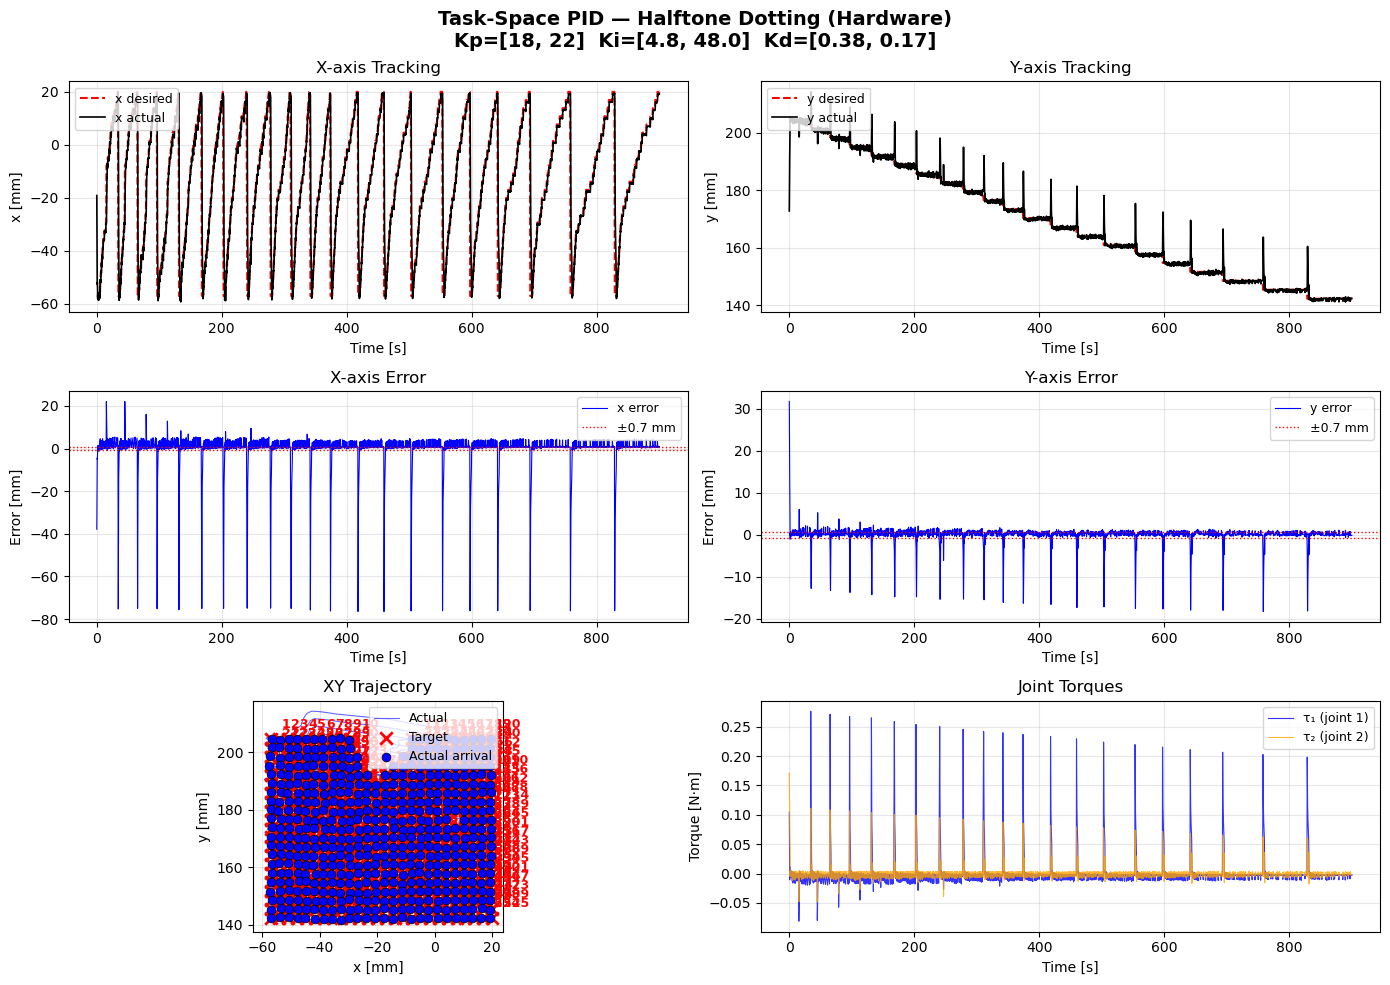

In [ ]:
if 'controller' not in dir() or len(controller.waypoint_logs) == 0:
    print("No data — run the trial cell first.")
else:
    t_all  = np.asarray(controller.time_stamps)
    ee_all = np.asarray(controller.ee_position_history) * 1000
    xd_all = np.asarray(controller.ee_desired_history)  * 1000
    err_all = np.asarray(controller.task_error_history)  * 1000
    tau_all = np.asarray(controller.torque_history)

    logs = controller.waypoint_logs
    tgt = np.array([wp['target_mm'] for wp in logs])
    act = np.array([wp['actual_mm'] for wp in logs])

    # ══════════════════════════════════════════════════════════════
    # TRACKING SUMMARY TABLE
    # ══════════════════════════════════════════════════════════════
    print("=" * 90)
    print(f"  TRACKING SUMMARY — {len(logs)} waypoints")
    print(f"  Kp={np.diag(K_P).tolist()}  Ki={np.diag(K_I).tolist()}  Kd={np.diag(K_D).tolist()}")
    print("=" * 90)
    print(f"  {'WP':>3}  {'Target X':>9}  {'Target Y':>9}  {'Actual X':>9}  {'Actual Y':>9}  "
          f"{'|Error|':>8}  {'Settle':>7}")
    print(f"  {'':>3}  {'(mm)':>9}  {'(mm)':>9}  {'(mm)':>9}  {'(mm)':>9}  "
          f"{'(mm)':>8}  {'(s)':>7}")
    print("-" * 90)

    errors_mm = []
    for wp in logs:
        err = wp['error_mm']
        errors_mm.append(err)
        print(f"  {wp['idx']+1:>3}  {wp['target_mm'][0]:>9.2f}  {wp['target_mm'][1]:>9.2f}  "
              f"{wp['actual_mm'][0]:>9.2f}  {wp['actual_mm'][1]:>9.2f}  "
              f"{err:>8.3f}  {wp['settle_time_s']:>7.2f}")

    errors_mm = np.array(errors_mm)
    print("-" * 90)
    print(f"  Mean |error|: {errors_mm.mean():.3f} mm    "
          f"Max |error|: {errors_mm.max():.3f} mm    "
          f"Std: {errors_mm.std():.3f} mm")
    print(f"  Total time:   {t_all[-1]:.1f} s    "
          f"Mean settle:  {np.mean([wp['settle_time_s'] for wp in logs]):.2f} s")
    print("=" * 90)

    # ══════════════════════════════════════════════════════════════
    # PLOTS
    # ══════════════════════════════════════════════════════════════
    fig = plt.figure(figsize=(14, 10), layout='constrained')
    fig.suptitle(
        f"Task-Space PID — Halftone Dotting (Hardware)\n"
        f"Kp={np.diag(K_P).tolist()}  Ki={np.diag(K_I).tolist()}  "
        f"Kd={np.diag(K_D).tolist()}",
        fontsize=14, fontweight='bold',
    )

    # ── 1. X-axis Tracking (top-left) ───────────────────────────
    ax1 = fig.add_subplot(3, 2, 1)
    ax1.plot(t_all, xd_all[:, 0], 'r--', lw=1.5, label='x desired')
    ax1.plot(t_all, ee_all[:, 0], 'k-',  lw=1.2, label='x actual')
    ax1.set_xlabel("Time [s]")
    ax1.set_ylabel("x [mm]")
    ax1.set_title("X-axis Tracking")
    ax1.legend(loc='upper left', fontsize=9)
    ax1.grid(True, alpha=0.3)

    # ── 2. Y-axis Tracking (top-right) ──────────────────────────
    ax2 = fig.add_subplot(3, 2, 2)
    ax2.plot(t_all, xd_all[:, 1], 'r--', lw=1.5, label='y desired')
    ax2.plot(t_all, ee_all[:, 1], 'k-',  lw=1.2, label='y actual')
    ax2.set_xlabel("Time [s]")
    ax2.set_ylabel("y [mm]")
    ax2.set_title("Y-axis Tracking")
    ax2.legend(loc='upper left', fontsize=9)
    ax2.grid(True, alpha=0.3)

    # ── 3. X-axis Error (mid-left) ──────────────────────────────
    ax3 = fig.add_subplot(3, 2, 3)
    ax3.plot(t_all, err_all[:, 0], 'b-', lw=0.8, label='x error')
    ax3.axhline(+controller.arrive_tol * 1000, ls=':', color='red', lw=1.0)
    ax3.axhline(-controller.arrive_tol * 1000, ls=':', color='red', lw=1.0,
                label=f'±{controller.arrive_tol*1000:.1f} mm')
    ax3.set_xlabel("Time [s]")
    ax3.set_ylabel("Error [mm]")
    ax3.set_title("X-axis Error")
    ax3.legend(loc='upper right', fontsize=9)
    ax3.grid(True, alpha=0.3)

    # ── 4. Y-axis Error (mid-right) ─────────────────────────────
    ax4 = fig.add_subplot(3, 2, 4)
    ax4.plot(t_all, err_all[:, 1], 'b-', lw=0.8, label='y error')
    ax4.axhline(+controller.arrive_tol * 1000, ls=':', color='red', lw=1.0)
    ax4.axhline(-controller.arrive_tol * 1000, ls=':', color='red', lw=1.0,
                label=f'±{controller.arrive_tol*1000:.1f} mm')
    ax4.set_xlabel("Time [s]")
    ax4.set_ylabel("Error [mm]")
    ax4.set_title("Y-axis Error")
    ax4.legend(loc='upper right', fontsize=9)
    ax4.grid(True, alpha=0.3)

    # ── 5. XY Trajectory (bottom-left) ──────────────────────────
    ax5 = fig.add_subplot(3, 2, 5)
    ax5.plot(ee_all[:, 0], ee_all[:, 1], 'b-', lw=0.8, alpha=0.6, label='Actual')
    ax5.scatter(tgt[:, 0], tgt[:, 1], s=80, c='red', marker='x', linewidths=2,
                zorder=5, label='Target')
    ax5.scatter(act[:, 0], act[:, 1], s=40, c='blue', edgecolors='black',
                linewidths=0.5, zorder=5, label='Actual arrival')
    for i in range(len(logs)):
        ax5.annotate(f"{i+1}", (tgt[i, 0], tgt[i, 1]),
                     textcoords="offset points", xytext=(8, 8),
                     fontsize=9, fontweight='bold', color='red')
        ax5.plot([tgt[i, 0], act[i, 0]], [tgt[i, 1], act[i, 1]],
                 'k--', lw=0.5, alpha=0.4)
    ax5.set_xlabel("x [mm]")
    ax5.set_ylabel("y [mm]")
    ax5.set_title("XY Trajectory")
    ax5.set_aspect('equal')
    ax5.legend(loc='upper right', fontsize=9)
    ax5.grid(True, alpha=0.3)

    # ── 6. Joint Torques (bottom-right) ─────────────────────────
    ax6 = fig.add_subplot(3, 2, 6)
    ax6.plot(t_all, tau_all[:, 0], 'b-', lw=0.8, alpha=0.8, label='τ₁ (joint 1)')
    ax6.plot(t_all, tau_all[:, 1], 'orange', lw=0.8, alpha=0.8, label='τ₂ (joint 2)')
    ax6.set_xlabel("Time [s]")
    ax6.set_ylabel("Torque [N·m]")
    ax6.set_title("Joint Torques")
    ax6.legend(loc='upper right', fontsize=9)
    ax6.grid(True, alpha=0.3)

    plt.tight_layout()

    # ══════════════════════════════════════════════════════════════
    # AUTO-SAVE FIGURE
    # ══════════════════════════════════════════════════════════════
    from pathlib import Path

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    gains_str = (f"Kp{int(np.diag(K_P)[0])}_Ki{int(np.diag(K_I)[0])}_"
                 f"Kd{int(np.diag(K_D)[0])}")
    save_name = f"halftone_PID_{gains_str}_{timestamp}.png"
    save_path = Path.home() / "Downloads" / save_name
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"\nFigure saved: {save_path}")

    plt.show()

XY figure saved: C:\Users\Ryman\Downloads\halftone_XY_Kp17_Ki4_Kd0_20260603_192506.png


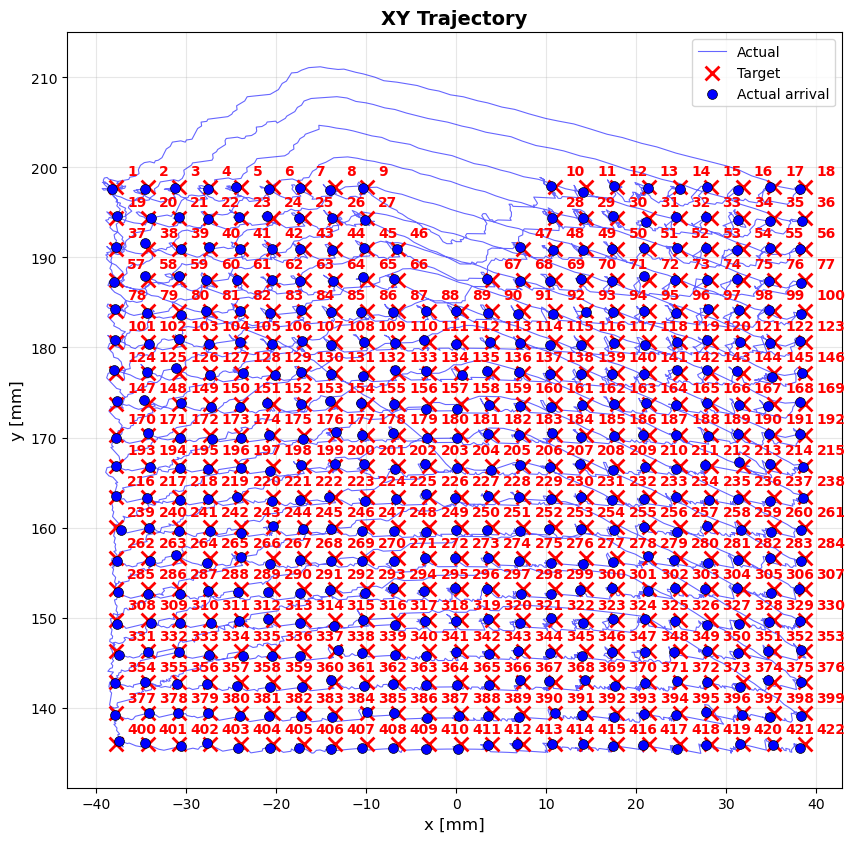

In [ ]:
# ══════════════════════════════════════════════════════════════
# SEPARATE XY TRAJECTORY PLOT
# ══════════════════════════════════════════════════════════════
fig_xy, ax_xy = plt.subplots(figsize=(10, 10))
ax_xy.plot(ee_all[:, 0], ee_all[:, 1], 'b-', lw=0.8, alpha=0.6, label='Actual')
ax_xy.scatter(tgt[:, 0], tgt[:, 1], s=100, c='red', marker='x', linewidths=2,
              zorder=5, label='Target')
ax_xy.scatter(act[:, 0], act[:, 1], s=50, c='blue', edgecolors='black',
              linewidths=0.5, zorder=5, label='Actual arrival')
for i in range(len(logs)):
    ax_xy.annotate(f"{i+1}", (tgt[i, 0], tgt[i, 1]),
                    textcoords="offset points", xytext=(8, 8),
                    fontsize=10, fontweight='bold', color='red')
    ax_xy.plot([tgt[i, 0], act[i, 0]], [tgt[i, 1], act[i, 1]],
                'k--', lw=0.5, alpha=0.4)
ax_xy.set_xlabel("x [mm]", fontsize=12)
ax_xy.set_ylabel("y [mm]", fontsize=12)
ax_xy.set_title("XY Trajectory", fontsize=14, fontweight='bold')
ax_xy.set_aspect('equal')
ax_xy.legend(fontsize=10)
ax_xy.grid(True, alpha=0.3)

save_name_xy = f"halftone_XY_{gains_str}_{timestamp}.png"
save_path_xy = Path.home() / "Downloads" / save_name_xy
fig_xy.savefig(save_path_xy, dpi=150, bbox_inches='tight')
print(f"XY figure saved: {save_path_xy}")
plt.show()